# Visualize Centerpoint Heatmap

In [2]:
import json
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.spatial.distance import cdist
import math
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.graph_objects as go
from pyquaternion import Quaternion

In [3]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

## 5.1 — Metrics aggregation (do this first — it's the skeleton everything else reads from)

### Metrics master table

In [104]:
rows = []

for folder in sorted(Path("../results/vast").iterdir()):
    if not folder.is_dir():
        continue
    
    summary_path = folder / "preds/pred_instances_3d/metrics_summary.json"
    if not summary_path.exists():
        print(f"skipping {folder.name}: no metrics_summary.json")
        continue

    with open(summary_path) as f:
        summary = json.load(f)
    
    for label, dist_aps in summary["label_aps"].items():
        for dist, ap in dist_aps.items():
            rows.append({
                "model": folder.name,
                "class": label,
                "metric": f"AP_dist_{dist}",
                "value": ap,
            })
        
        for tp_error, val in summary["label_tp_errors"][label].items():
            rows.append({
                "model": folder.name,
                "class": label,
                "metric": tp_error,
                "value": val,
            })

df = pd.DataFrame(rows, columns=["model", "class", "metric", "value"])
df.to_csv("../results/metrics_master.csv", index=False)

### Headline table

In [103]:
rows = []

for folder in sorted(Path("../results/vast").iterdir()):
    if not folder.is_dir():
        continue
    
    summary_path = folder / "preds/pred_instances_3d/metrics_summary.json"
    if not summary_path.exists():
        print(f"skipping {folder.name}: no metrics_summary.json")
        continue

    with open(summary_path) as f:
        summary = json.load(f)

    rows.append([folder.name, summary["mean_ap"], summary["nd_score"], *summary["tp_errors"].values()])

df = pd.DataFrame(rows, columns=["Model", "mAP↑", "NDS↑", "mATE↓", "mASE↓", "mAOE↓", "mAVE↓", "mAAE↓"])
# df.round(2).to_markdown()

# 5.2 — Per-class & per-distance breakdown

### plot a per-class AP heatmap (model × class)

In [114]:
sub_df = master_df[master_df["metric"]=="AP_dist_2.0"]
sub_df.head(2)

,model,class,metric,value
2,bevfusion_lidar,car,AP_dist_2.0,0.905205
11,bevfusion_lidar,truck,AP_dist_2.0,0.673399


In [113]:
wide_sub_df = sub_df.pivot(index="model", columns="class", values="value")
wide_sub_df.head(2)

class,barrier,bicycle,bus,car,construction_vehicle,motorcycle,pedestrian,traffic_cone,trailer,truck
model,,,,,,,,,,
bevfusion_lidar,0.737240,0.554538,0.854048,0.905205,0.336851,0.724199,0.868945,0.740520,0.575216,0.673399
bevfusion_lidar_cam,0.755804,0.629082,0.887452,0.927197,0.387727,0.792750,0.885210,0.794862,0.609248,0.722024


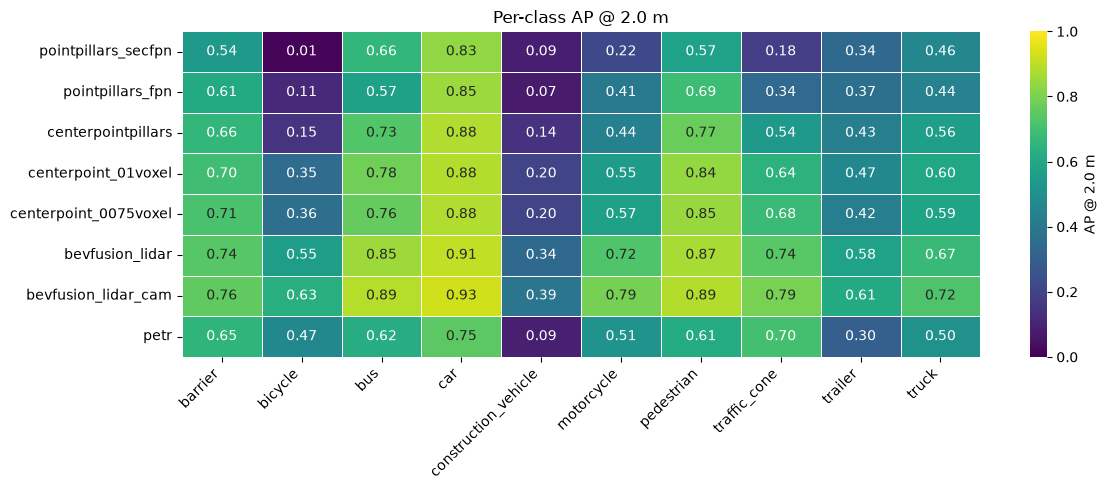

In [129]:
df = pd.read_csv("../results/metrics_master.csv")

sub_df = df[df["metric"]=="AP_dist_2.0"]
wide_sub_df = sub_df.pivot(index="model", columns="class", values="value")
model_order = [
    "pointpillars_secfpn", "pointpillars_fpn",
    "centerpointpillars", "centerpoint_01voxel", "centerpoint_0075voxel",
    "bevfusion_lidar", "bevfusion_lidar_cam", "petr",
]
wide_sub_df = wide_sub_df.reindex(model_order)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    wide_sub_df,
    annot=True, fmt=".2f",
    vmin=0, vmax=1,
    cmap="viridis", # "RdYlGn"
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "AP @ 2.0 m"},
    ax=ax,
)

ax.set_title("Per-class AP @ 2.0 m")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("./outputs/plots/per_class_ap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Evaluations per Bin

In [4]:
from nuscenes import NuScenes
from nuscenes.eval.common.loaders import add_center_dist, load_gt, load_prediction, filter_eval_boxes
from nuscenes.eval.common.utils import center_distance
from nuscenes.eval.common.data_classes import EvalBoxes
from nuscenes.eval.detection.data_classes import DetectionBox
from nuscenes.eval.detection.config import config_factory
from nuscenes.eval.detection.algo import accumulate, calc_ap

from tqdm import tqdm

In [4]:
nusc = NuScenes(version="v1.0-trainval", dataroot="../data/nuscenes/")

Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 23.077 seconds.
Reverse indexing ...
Done reverse indexing in 6.0 seconds.


In [5]:
cfg = config_factory("detection_cvpr_2019")

gt_boxes = load_gt(nusc, "val", DetectionBox)
add_center_dist(nusc, gt_boxes) # Mutates gt_boxes inplace

filter_eval_boxes( # Mutates gt_boxes inplace
    nusc=nusc,
    eval_boxes=gt_boxes,
    max_dist=cfg.class_range,
)

EvalBoxes with 121861 boxes across 6019 samples

### Filter both gt and pred boxes that are too far away. Also remove gt boxes with too few points.

- Something that was done in `test.py` after prediction, before calculating the eval metrics.

### Build one frame for gt and one for pred and add range and bin

In [6]:
from scripts.evaluation.common import run_bin_metric_chain

In [7]:
for path in Path("../results/vast/").iterdir():
    model_name = path.name
    path = path / "preds/pred_instances_3d/results_nusc.json"
    dest_path = Path("../results/eval/") / model_name
    dest_path.mkdir(parents=True, exist_ok=True)
    
    run_bin_metric_chain(
        nusc=nusc,
        gt_boxes=gt_boxes,
        result_file_path=path,
        bins=[[0, 20], [20, 30], [30, 40], [40, 50]],
        threshold=2,
        dist_thresholds=[0.5, 1.0, 2.0, 4.0],
        cfg=cfg,
        dest_path=dest_path,
    )

petr
bevfusion_lidar_cam
pointpillars_secfpn
pointpillars_fpn
centerpoint_0075voxel
bevfusion_lidar
centerpoint_01voxel
centerpointpillars


### 

In [63]:
rows = []
for path in Path("../results/eval/").iterdir():
    recall_df = pd.read_csv(path / "recall_df.csv")
    ap_df = pd.read_csv(path / "ap_df.csv")
    binned_df = pd.read_csv(path / "binned_df.csv")

    recall_df["model"] = path.name
    recall_df["metric"] = "recall"

    ap_df = ap_df[["class", "bin", "ap"]]
    ap_df["model"] = path.name
    ap_df["metric"] = "ap"
    
    rows.extend(recall_df.values.tolist())
    rows.extend(ap_df.values.tolist())

long_df = pd.DataFrame(rows, columns=["class", "bin", "value", "model", "metric"])

### recall-vs-range line plot, one line per model (overall, class-averaged)

In [34]:
recall_df = long_df[long_df["metric"] == "recall"]

class_avg_df = recall_df.groupby(["model", "bin"], observed=True)["value"].mean().reset_index()

bin_order = ["0-20", "20-30", "30-40", "40-50"]
class_avg_df["bin"] = pd.Categorical(class_avg_df["bin"], categories=bin_order, ordered=True)
class_avg_df = class_avg_df.sort_values("bin")

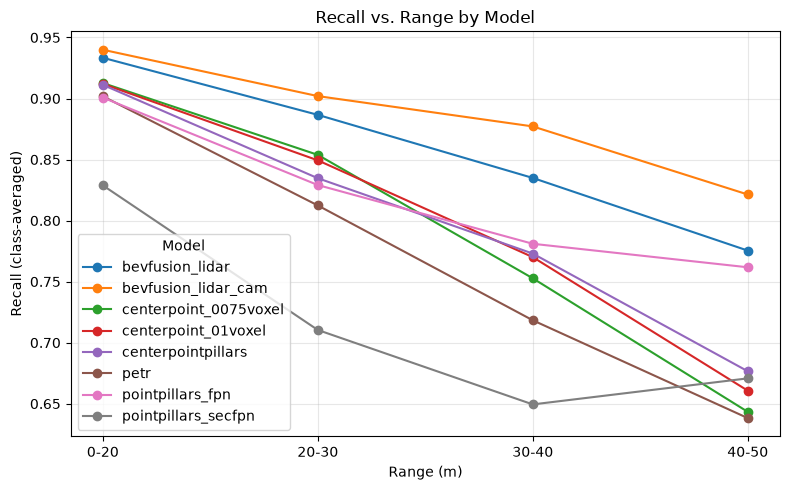

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
for model, group in class_avg_df.groupby("model", observed=True):
    ax.plot(group["bin"].astype(str), group["value"], marker="o", label=model)

ax.set_xlabel("Range (m)")
ax.set_ylabel("Recall (class-averaged)")
ax.set_title("Recall vs. Range by Model")
ax.legend(title="Model")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### per-class × bin heatmap for one model

In [64]:
model_name = "petr"

model_recall_df = long_df[(long_df["metric"] == "recall") & (long_df["model"] == model_name)]
wide_df = sub.pivot_table(index="class", columns="bin", values="value", observed=True)

bin_order = ["0-20", "20-30", "30-40", "40-50"]
wide_df = wide_df.reindex(columns=bin_order)
wide_df = wide_df.sort_values(bin_order[-1], ascending=False)

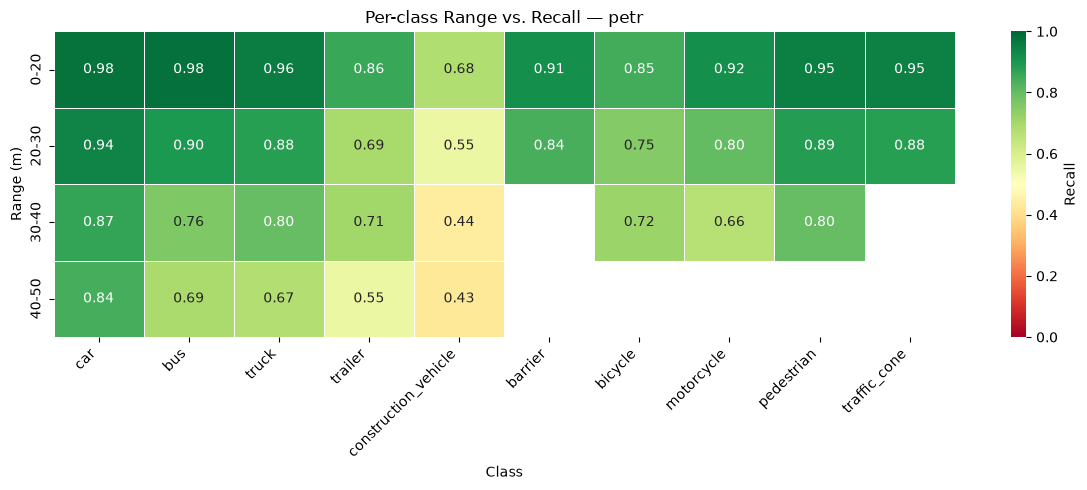

In [65]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    wide_df.T,
    annot=True, fmt=".2f",          # show the numbers in each cell
    cmap="RdYlGn",                  # red=low recall, green=high — reads intuitively
    vmin=0, vmax=1,                 # pin scale to recall's 0–1 range
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Recall"},
    ax=ax,
)
ax.set_xlabel("Class")
ax.set_ylabel("Range (m)")
ax.set_title(f"Per-class Range vs. Recall — {model_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5.3 Conditional slices (day/night, rain/clear)

In [ ]:
def npos_by(ap_df, c, cls):
    return int(ap_df[(ap_df.condition==c)&(ap_df["class"]==cls)]["npos"].sum())

def paired_compare(ap_df, base, cond):
    wide = ap_df[
        ap_df["condition"].isin([cond, base])
    ].pivot_table(index="class", columns="condition", values="ap", observed=True)
    
    paired = wide.dropna(subset=[cond, base]).copy()
    
    rows = []
    for cls in paired.index.get_level_values("class").unique():
        sub = paired.loc[cls]
        rows.append([cls, sub[base].mean(), sub[cond].mean(), npos_by(ap_df, base, cls), npos_by(ap_df, cond, cls)])
    
    per_class = pd.DataFrame(
        rows,
        columns=["class", f"{base}_AP", f"{cond}_AP", f"{base}_gt", f"{cond}_gt"]
    ).sort_values(f"{cond}_gt", ascending=False)
    return per_class

In [55]:
day_vs_night_rows = []
clear_vs_rain_rows = []
for path in Path("../results/eval/").iterdir():
    cond_ap_df = pd.read_csv(path / "cond_ap_df.csv")
    
    clear_day_vs_rain_df = paired_compare(cond_ap_df, "clear_day", "rain")
    clear_day_vs_rain_df["model"] = path.name
    clear_day_vs_rain_df["ap_delta"] = clear_day_vs_rain_df["clear_day_AP"] - clear_day_vs_rain_df["rain_AP"]
    clear_vs_rain_rows.extend(clear_day_vs_rain_df[["model", "class", "ap_delta"]].values.tolist())
    
    clear_day_vs_night_df = paired_compare(cond_ap_df, "clear_day", "night")
    clear_day_vs_night_df["model"] = path.name
    clear_day_vs_night_df["ap_delta"] = clear_day_vs_night_df["clear_day_AP"] - clear_day_vs_night_df["night_AP"]
    day_vs_night_rows.extend(clear_day_vs_night_df[["model", "class", "ap_delta"]].values.tolist())

clear_vs_rain_df = pd.DataFrame(clear_vs_rain_rows, columns=["model", "class", "delta (Clear AP - Rain AP)"])
day_vs_night_df = pd.DataFrame(day_vs_night_rows, columns=["model", "class", "delta (Day AP - Night AP)"])

In [58]:
# clear_vs_rain_df[clear_vs_rain_df["model"].isin(["bevfusion_lidar", "bevfusion_lidar_cam"])]
# day_vs_night_df[day_vs_night_df["model"].isin(["bevfusion_lidar", "bevfusion_lidar_cam"])]

In [132]:
nusc.table_names

['category',
 'attribute',
 'visibility',
 'instance',
 'sensor',
 'calibrated_sensor',
 'ego_pose',
 'log',
 'scene',
 'sample',
 'sample_data',
 'sample_annotation',
 'map']

In [137]:
nusc.ego_pose[0]

{'token': 'bddd80ae33ec4e32b27fdb3c1160a30e',
 'timestamp': 1531883530440378,
 'rotation': [-0.7504501527141022,
  -0.0076295847961364415,
  0.00847103369020136,
  -0.6608287216181199],
 'translation': [1010.1273947164545, 610.7727090350685, 0.0]}

In [138]:
nusc.sample[0]

{'token': 'e93e98b63d3b40209056d129dc53ceee',
 'timestamp': 1531883530449377,
 'prev': '',
 'next': '14d5adfe50bb4445bc3aa5fe607691a8',
 'scene_token': '73030fb67d3c46cfb5e590168088ae39',
 'data': {'RADAR_FRONT': 'bddd80ae33ec4e32b27fdb3c1160a30e',
  'RADAR_FRONT_LEFT': '1a08aec0958e42ebb37d26612a2cfc57',
  'RADAR_FRONT_RIGHT': '282fa8d7a3f34b68b56fb1e22e697668',
  'RADAR_BACK_LEFT': '05fc4678025246f3adf8e9b8a0a0b13b',
  'RADAR_BACK_RIGHT': '31b8099fb1c44c6381c3c71b335750bb',
  'LIDAR_TOP': '3388933b59444c5db71fade0bbfef470',
  'CAM_FRONT': '020d7b4f858147558106c504f7f31bef',
  'CAM_FRONT_RIGHT': '16d39ff22a8545b0a4ee3236a0fe1c20',
  'CAM_BACK_RIGHT': 'ec7096278e484c9ebe6894a2ad5682e9',
  'CAM_BACK': 'aab35aeccbda42de82b2ff5c278a0d48',
  'CAM_BACK_LEFT': '86e6806d626b4711a6d0f5015b090116',
  'CAM_FRONT_LEFT': '24332e9c554a406f880430f17771b608'},
 'anns': ['173a50411564442ab195e132472fde71',
  '5123ed5e450948ac8dc381772f2ae29a',
  'acce0b7220754600b700257a1de1573d',
  '8d7cb5e96cae48c39

In [139]:
nusc.sample[0]["anns"][0]

'173a50411564442ab195e132472fde71'

In [ ]:
nusc.get()

In [140]:
nusc.sample_annotation[0]

{'token': '2cd832644d09479389ed0785e5de85c9',
 'sample_token': 'c36eb85918a84a788e236f5c9eef2b05',
 'instance_token': '5e2b6fd1fab74d04a79eefebbec357bb',
 'visibility_token': '3',
 'attribute_tokens': [],
 'translation': [993.884, 612.441, 0.675],
 'size': [0.3, 0.291, 0.734],
 'rotation': [-0.04208490861058176, 0.0, 0.0, 0.9991140377690821],
 'prev': '5cd018cb2448415ab8aff4dc7256999a',
 'next': '',
 'num_lidar_pts': 2,
 'num_radar_pts': 0,
 'category_name': 'movable_object.trafficcone'}

In [158]:
gt_boxes.boxes["fd8420396768425eabec9bdddf7e64b6"][0]

{'sample_token': 'fd8420396768425eabec9bdddf7e64b6', 'translation': [242.87, 926.036, 0.898], 'size': [1.726, 4.257, 1.489], 'rotation': [0.787419398050721, 0.0, 0.0, -0.616417627565468], 'velocity': array([ 0.16021727, -0.69494243]), 'ego_translation': (0, 0, 0), 'num_pts': 173, 'detection_name': 'car', 'detection_score': -1.0, 'attribute_name': 'vehicle.moving'}

In [141]:
import nuscenes

In [ ]:
nuscenes.eval.commo